# 1. Problem Breakdown

## Bối cảnh
Bộ phận Marketing muốn hiểu hành trình của khách hàng từ nguồn truy cập website đến trang đầu tiên họ vào, sau đó xem họ có mua sản phẩm hay rời khỏi website.

## Mục tiêu phân tích
Xây dựng biểu đồ Sankey đa tầng thể hiện luồng:

`utm_source → landing_page → product_name / None (Drop-off)`

## Câu hỏi cần trả lời
1. Khách hàng từ nguồn Marketing nào có tỷ lệ chuyển đổi thành đơn hàng cao nhất?
2. Landing Page nào thu hút nhiều khách nhưng có tỷ lệ Drop-off cao?
3. Hành vi mua sắm của khách đến từ `gsearch` và `bsearch` khác nhau như thế nào?

## Output cuối cùng
- Bảng kiểm tra chất lượng dữ liệu cơ bản.
- Bảng Master Journey gồm: `utm_source`, `landing_page`, `product_name`.
- Bảng dữ liệu Source - Target dùng cho Sankey.
- Biểu đồ Sankey đa tầng bằng Plotly.
- Bảng và nhận xét trả lời 3 câu hỏi insight.

## Assumption
- Chỉ phân tích các session có `utm_source` khác null vì requirement tập trung vào nguồn Marketing.
- Các session không có đơn hàng sẽ được gán `product_name = "None (Drop-off)"`.
- Sản phẩm được lấy theo `primary_product_id` trong bảng `orders`, sau đó join với bảng `products`.

# 2. Data Selection & Preprocessing

## Bảng cần dùng

### 1. website_sessions
Dùng để lấy nguồn traffic của từng session.
- `website_session_id`
- `created_at`
- `utm_source`

### 2. website_pageviews
Dùng để xác định trang đầu tiên khách truy cập trong mỗi session.
- `website_pageview_id`
- `website_session_id`
- `created_at`
- `pageview_url`

### 3. orders
Dùng để biết session nào có phát sinh đơn hàng.
- `order_id`
- `website_session_id`
- `primary_product_id`

### 4. products
Dùng để lấy tên sản phẩm từ `primary_product_id`.
- `product_id`
- `product_name`


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

# Đường dẫn file trên Google Colab
sessions_path = "/content/website_sessions.csv"
pageviews_path = "/content/website_pageviews.csv"
orders_path = "/content/orders.csv"
products_path = "/content/products.csv"

# Chỉ đọc các cột cần thiết cho bài toán
sessions = pd.read_csv(
    sessions_path,
    usecols=["website_session_id", "created_at", "utm_source"]
)

pageviews = pd.read_csv(
    pageviews_path,
    usecols=["website_pageview_id", "website_session_id", "created_at", "pageview_url"]
)

orders = pd.read_csv(
    orders_path,
    usecols=["order_id", "website_session_id", "primary_product_id"]
)

products = pd.read_csv(
    products_path,
    usecols=["product_id", "product_name"]
)

print("Loaded data successfully.")
print("sessions:", sessions.shape)
print("pageviews:", pageviews.shape)
print("orders:", orders.shape)
print("products:", products.shape)

Loaded data successfully.
sessions: (472871, 3)
pageviews: (1188124, 4)
orders: (32313, 3)
products: (4, 2)


## Kiểm tra dữ liệu cơ bản

Ta kiểm tra:
- Số dòng, số cột.
- Duplicate theo toàn bộ dòng.
- Duplicate theo khóa chính.
- Missing values ở các cột quan trọng.
- Kiểu dữ liệu hiện tại.

Mục tiêu của bước này là đảm bảo dữ liệu đủ sạch để join và phân tích Sankey.

In [ ]:
tables = {
    "website_sessions": sessions,
    "website_pageviews": pageviews,
    "orders": orders,
    "products": products
}

primary_keys = {
    "website_sessions": "website_session_id",
    "website_pageviews": "website_pageview_id",
    "orders": "order_id",
    "products": "product_id"
}

quality_rows = []

for table_name, df in tables.items():
    pk = primary_keys[table_name]

    quality_rows.append({
        "table": table_name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "duplicate_primary_key": df[pk].duplicated().sum()
    })

quality_summary = pd.DataFrame(quality_rows)
display(quality_summary)

,table,rows,columns,duplicate_rows,duplicate_primary_key
0,website_sessions,472871,3,0,0
1,website_pageviews,1188124,4,0,0
2,orders,32313,3,0,0
3,products,4,2,0,0


In [ ]:
missing_rows = []

important_columns = {
    "website_sessions": ["website_session_id", "created_at", "utm_source"],
    "website_pageviews": ["website_pageview_id", "website_session_id", "created_at", "pageview_url"],
    "orders": ["order_id", "website_session_id", "primary_product_id"],
    "products": ["product_id", "product_name"]
}

for table_name, cols in important_columns.items():
    df = tables[table_name]

    for col in cols:
        missing_rows.append({
            "table": table_name,
            "column": col,
            "dtype": str(df[col].dtype),
            "missing_values": df[col].isna().sum(),
            "missing_rate": df[col].isna().mean()
        })

missing_summary = pd.DataFrame(missing_rows)
display(missing_summary.style.format({"missing_rate": "{:.2%}"}))

,table,column,dtype,missing_values,missing_rate
0,website_sessions,website_session_id,int64,0,0.00%
1,website_sessions,created_at,object,0,0.00%
2,website_sessions,utm_source,object,83328,17.62%
3,website_pageviews,website_pageview_id,int64,0,0.00%
4,website_pageviews,website_session_id,int64,0,0.00%
5,website_pageviews,created_at,object,0,0.00%
6,website_pageviews,pageview_url,object,0,0.00%
7,orders,order_id,int64,0,0.00%
8,orders,website_session_id,int64,0,0.00%
9,orders,primary_product_id,int64,0,0.00%


## Làm sạch dữ liệu ở mức cần thiết

Các bước làm sạch cần cho bài toán:
1. Chuyển các cột `created_at` sang datetime.
2. Giữ lại các session có `utm_source` khác null vì bài toán tập trung vào nguồn Marketing.
3. Không xử lý thêm các cột không phục vụ trực tiếp requirement.

In [ ]:
# Chuyển cột thời gian sang datetime
sessions["created_at"] = pd.to_datetime(sessions["created_at"], errors="coerce")
pageviews["created_at"] = pd.to_datetime(pageviews["created_at"], errors="coerce")

# Chỉ giữ các session có nguồn Marketing
sessions_marketing = sessions.dropna(subset=["utm_source"]).copy()

print("Số session ban đầu:", sessions.shape[0])
print("Số session có utm_source:", sessions_marketing.shape[0])
print("Các nguồn traffic trong dữ liệu:")
display(sessions_marketing["utm_source"].value_counts().reset_index(name="sessions"))

Số session ban đầu: 472871
Số session có utm_source: 389543
Các nguồn traffic trong dữ liệu:


,utm_source,sessions
0,gsearch,316035
1,bsearch,62823
2,socialbook,10685


# 3. Analysis & Visualization

## Bước 1: Xác định Landing Page

Một session có thể có nhiều pageviews. Landing Page là trang đầu tiên của mỗi `website_session_id`, xác định bằng cách sắp xếp theo:
1. `website_session_id`
2. `created_at`
3. `website_pageview_id`

Sau đó lấy dòng đầu tiên của mỗi session.

In [ ]:
landing_pages = (
    pageviews
    .sort_values(["website_session_id", "created_at", "website_pageview_id"])
    .drop_duplicates(subset=["website_session_id"], keep="first")
    .rename(columns={"pageview_url": "landing_page"})
    [["website_session_id", "landing_page"]]
)

print("Số landing page được xác định:", landing_pages.shape[0])
display(landing_pages.head())

Số landing page được xác định: 472871


,website_session_id,landing_page
0,1,/home
1,2,/home
2,3,/home
3,4,/home
4,5,/home


## Bước 2 và 3: Tạo Master Journey

Ta tạo bảng Master Journey bằng cách:

1. Join `website_sessions` với `landing_pages` để lấy `utm_source` và `landing_page`.
2. Join `orders` với `products` để lấy `product_name`.
3. Left Join session với orders để giữ cả những session không mua hàng.
4. Các session không có `order_id` được gán `product_name = "None (Drop-off)"`.

Kết quả cuối cùng là bảng có 3 thông tin chính:
- `utm_source`
- `landing_page`
- `product_name`

In [ ]:
# Join orders với products để lấy tên sản phẩm chính của đơn hàng
orders_with_products = orders.merge(
    products,
    left_on="primary_product_id",
    right_on="product_id",
    how="left"
)

# Tạo Master Journey
master_journey = (
    sessions_marketing
    .merge(landing_pages, on="website_session_id", how="left")
    .merge(
        orders_with_products[["website_session_id", "order_id", "product_name"]],
        on="website_session_id",
        how="left"
    )
)

# Xử lý session không có landing page hoặc không có đơn hàng
master_journey["landing_page"] = master_journey["landing_page"].fillna("Unknown Landing Page")
master_journey["product_name"] = master_journey["product_name"].fillna("None (Drop-off)")
master_journey["is_order"] = master_journey["order_id"].notna().astype(int)

display(master_journey.head())
print("Kích thước Master Journey:", master_journey.shape)

,website_session_id,created_at,utm_source,landing_page,order_id,product_name,is_order
0,1,2012-03-19 08:04:16,gsearch,/home,NaN,None (Drop-off),0
1,2,2012-03-19 08:16:49,gsearch,/home,NaN,None (Drop-off),0
2,3,2012-03-19 08:26:55,gsearch,/home,NaN,None (Drop-off),0
3,4,2012-03-19 08:37:33,gsearch,/home,NaN,None (Drop-off),0
4,5,2012-03-19 09:00:55,gsearch,/home,NaN,None (Drop-off),0


Kích thước Master Journey: (389543, 7)


## Kiểm tra nhanh Master Journey

Trước khi tạo Sankey, ta kiểm tra:
- Số session theo từng nguồn traffic.
- Số lượng session mua hàng và không mua hàng.
- Một session chỉ nên xuất hiện một dòng trong Master Journey.

In [ ]:
master_check = pd.DataFrame({
    "metric": [
        "total_rows",
        "unique_sessions",
        "duplicated_sessions",
        "orders",
        "dropoff_sessions"
    ],
    "value": [
        master_journey.shape[0],
        master_journey["website_session_id"].nunique(),
        master_journey["website_session_id"].duplicated().sum(),
        master_journey["order_id"].notna().sum(),
        master_journey["order_id"].isna().sum()
    ]
})

display(master_check)

display(
    master_journey["utm_source"]
    .value_counts()
    .reset_index(name="sessions")
)

,metric,value
0,total_rows,389543
1,unique_sessions,389543
2,duplicated_sessions,0
3,orders,26195
4,dropoff_sessions,363348


,utm_source,sessions
0,gsearch,316035
1,bsearch,62823
2,socialbook,10685


## Bước 4: Tạo dữ liệu Source - Target cho Sankey

Biểu đồ Sankey cần dữ liệu dạng cặp `source`, `target`, `value`.

Ta tạo 2 tầng:

### Tầng 1
`utm_source → landing_page`

### Tầng 2
`landing_page → product_name`

Sau đó nối 2 bảng lại bằng `pd.concat()`.

In [ ]:
# Tầng 1: utm_source -> landing_page
layer_1 = (
    master_journey
    .groupby(["utm_source", "landing_page"], as_index=False)
    .agg(value=("website_session_id", "nunique"))
    .rename(columns={
        "utm_source": "source",
        "landing_page": "target"
    })
)

# Tầng 2: landing_page -> product_name
layer_2 = (
    master_journey
    .groupby(["landing_page", "product_name"], as_index=False)
    .agg(value=("website_session_id", "nunique"))
    .rename(columns={
        "landing_page": "source",
        "product_name": "target"
    })
)

sankey_links = pd.concat([layer_1, layer_2], ignore_index=True)

display(sankey_links.head(10))
print("Số link trong Sankey:", sankey_links.shape[0])

,source,target,value
0,bsearch,/home,7914
1,bsearch,/lander-1,9459
2,bsearch,/lander-2,24076
3,bsearch,/lander-3,6178
4,bsearch,/lander-4,1903
5,bsearch,/lander-5,13293
6,gsearch,/home,46334
7,gsearch,/lander-1,38115
8,gsearch,/lander-2,100982
9,gsearch,/lander-3,68249


Số link trong Sankey: 41


## Bước 5: Vẽ biểu đồ Sankey bằng Plotly

Biểu đồ thể hiện luồng khách hàng theo 3 tầng:

`Nguồn Marketing → Landing Page → Sản phẩm / Drop-off`

Độ dày của mỗi luồng thể hiện số lượng session đi theo luồng đó.

In [ ]:
# Tạo danh sách node duy nhất
all_nodes = pd.Index(
    pd.concat([sankey_links["source"], sankey_links["target"]]).unique()
)

node_map = {node: idx for idx, node in enumerate(all_nodes)}

# Map source và target từ text sang index
sankey_links["source_id"] = sankey_links["source"].map(node_map)
sankey_links["target_id"] = sankey_links["target"].map(node_map)

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=20,
                thickness=18,
                label=all_nodes.tolist()
            ),
            link=dict(
                source=sankey_links["source_id"],
                target=sankey_links["target_id"],
                value=sankey_links["value"]
            )
        )
    ]
)

fig.update_layout(
    title_text="Customer Journey Sankey: Marketing Source → Landing Page → Product / Drop-off",
    font_size=11,
    height=700
)

fig.show()

# 4. Insights & Recommendations

Phần này trả lời trực tiếp 3 câu hỏi trong requirement:

1. Nguồn traffic nào có tỷ lệ chuyển đổi thành đơn hàng cao nhất?
2. Landing Page nào thu hút nhiều khách nhưng có tỷ lệ Drop-off cao?
3. Sự khác biệt về hành vi mua sắm giữa khách đến từ `gsearch` và `bsearch`.

Các nhận xét chỉ dựa trên kết quả đã tính từ Master Journey.

## Câu hỏi 1: Nguồn traffic nào có tỷ lệ chuyển đổi thành đơn hàng cao nhất?

Cách tính:

`conversion_rate = số session có order / tổng số session`

In [ ]:
source_conversion = (
    master_journey
    .groupby("utm_source", as_index=False)
    .agg(
        sessions=("website_session_id", "nunique"),
        orders=("order_id", "count")
    )
)

source_conversion["conversion_rate"] = (
    source_conversion["orders"] / source_conversion["sessions"]
)

source_conversion = source_conversion.sort_values(
    "conversion_rate",
    ascending=False
)

display(
    source_conversion.style.format({
        "conversion_rate": "{:.2%}"
    })
)

,utm_source,sessions,orders,conversion_rate
0,bsearch,62823,4519,7.19%
1,gsearch,316035,21333,6.75%
2,socialbook,10685,343,3.21%


In [ ]:
best_source = source_conversion.iloc[0]

print(
    f"Nguồn traffic có tỷ lệ chuyển đổi cao nhất là {best_source['utm_source']} "
    f"với conversion rate khoảng {best_source['conversion_rate']:.2%}."
)

Nguồn traffic có tỷ lệ chuyển đổi cao nhất là bsearch với conversion rate khoảng 7.19%.


## Câu hỏi 2: Landing Page nào thu hút nhiều khách nhưng Drop-off cao?

Cách tính:

- `sessions`: tổng số session vào landing page đó.
- `orders`: số session có phát sinh đơn hàng.
- `dropoff_sessions = sessions - orders`
- `dropoff_rate = dropoff_sessions / sessions`

Để xác định landing page đáng chú ý, ta ưu tiên xem các landing page có lượng session lớn và drop-off rate cao.

In [ ]:
landing_dropoff = (
    master_journey
    .groupby("landing_page", as_index=False)
    .agg(
        sessions=("website_session_id", "nunique"),
        orders=("order_id", "count")
    )
)

landing_dropoff["dropoff_sessions"] = (
    landing_dropoff["sessions"] - landing_dropoff["orders"]
)

landing_dropoff["dropoff_rate"] = (
    landing_dropoff["dropoff_sessions"] / landing_dropoff["sessions"]
)

landing_dropoff["conversion_rate"] = (
    landing_dropoff["orders"] / landing_dropoff["sessions"]
)

landing_dropoff = landing_dropoff.sort_values(
    ["sessions", "dropoff_rate"],
    ascending=[False, False]
)

display(
    landing_dropoff.style.format({
        "dropoff_rate": "{:.2%}",
        "conversion_rate": "{:.2%}"
    })
)

,landing_page,sessions,orders,dropoff_sessions,dropoff_rate,conversion_rate
2,/lander-2,131170,10128,121042,92.28%,7.72%
3,/lander-3,79000,2679,76321,96.61%,3.39%
5,/lander-5,68166,6930,61236,89.83%,10.17%
0,/home,54248,3593,50655,93.38%,6.62%
1,/lander-1,47574,2157,45417,95.47%,4.53%
4,/lander-4,9385,708,8677,92.46%,7.54%


In [ ]:
# Landing page có traffic cao: sessions >= median sessions của các landing page
traffic_threshold = landing_dropoff["sessions"].median()

high_traffic_high_dropoff = (
    landing_dropoff[
        landing_dropoff["sessions"] >= traffic_threshold
    ]
    .sort_values("dropoff_rate", ascending=False)
)

display(
    high_traffic_high_dropoff.style.format({
        "dropoff_rate": "{:.2%}",
        "conversion_rate": "{:.2%}"
    })
)

top_problem_landing = high_traffic_high_dropoff.iloc[0]

print(
    f"Landing Page cần chú ý nhất là {top_problem_landing['landing_page']} "
    f"vì có {top_problem_landing['sessions']:,} sessions "
    f"và drop-off rate khoảng {top_problem_landing['dropoff_rate']:.2%}."
)

,landing_page,sessions,orders,dropoff_sessions,dropoff_rate,conversion_rate
3,/lander-3,79000,2679,76321,96.61%,3.39%
2,/lander-2,131170,10128,121042,92.28%,7.72%
5,/lander-5,68166,6930,61236,89.83%,10.17%


Landing Page cần chú ý nhất là /lander-3 vì có 79,000 sessions và drop-off rate khoảng 96.61%.


## Câu hỏi 3: Sự khác biệt giữa gsearch và bsearch

Ta so sánh:
1. Tổng số session.
2. Số đơn hàng.
3. Conversion rate.
4. Tỷ trọng session rơi vào từng sản phẩm hoặc Drop-off.

In [ ]:
gb_journey = master_journey[
    master_journey["utm_source"].isin(["gsearch", "bsearch"])
].copy()

gb_conversion = (
    gb_journey
    .groupby("utm_source", as_index=False)
    .agg(
        sessions=("website_session_id", "nunique"),
        orders=("order_id", "count")
    )
)

gb_conversion["conversion_rate"] = (
    gb_conversion["orders"] / gb_conversion["sessions"]
)

display(
    gb_conversion.sort_values("conversion_rate", ascending=False)
    .style.format({
        "conversion_rate": "{:.2%}"
    })
)

,utm_source,sessions,orders,conversion_rate
0,bsearch,62823,4519,7.19%
1,gsearch,316035,21333,6.75%


In [ ]:
gb_product_mix = (
    gb_journey
    .groupby(["utm_source", "product_name"], as_index=False)
    .agg(sessions=("website_session_id", "nunique"))
)

gb_total_sessions = (
    gb_journey
    .groupby("utm_source", as_index=False)
    .agg(total_sessions=("website_session_id", "nunique"))
)

gb_product_mix = gb_product_mix.merge(
    gb_total_sessions,
    on="utm_source",
    how="left"
)

gb_product_mix["session_share"] = (
    gb_product_mix["sessions"] / gb_product_mix["total_sessions"]
)

gb_product_mix = gb_product_mix.sort_values(
    ["utm_source", "sessions"],
    ascending=[True, False]
)

display(
    gb_product_mix.style.format({
        "session_share": "{:.2%}"
    })
)

,utm_source,product_name,sessions,total_sessions,session_share
0,bsearch,None (Drop-off),58304,62823,92.81%
4,bsearch,The Original Mr. Fuzzy,3360,62823,5.35%
2,bsearch,The Forever Love Bear,648,62823,1.03%
1,bsearch,The Birthday Sugar Panda,425,62823,0.68%
3,bsearch,The Hudson River Mini bear,86,62823,0.14%
5,gsearch,None (Drop-off),294702,316035,93.25%
9,gsearch,The Original Mr. Fuzzy,15853,316035,5.02%
7,gsearch,The Forever Love Bear,3152,316035,1.00%
6,gsearch,The Birthday Sugar Panda,1951,316035,0.62%
8,gsearch,The Hudson River Mini bear,377,316035,0.12%


In [ ]:
# So sánh riêng các đơn hàng, loại bỏ Drop-off
gb_orders_only = gb_journey[
    gb_journey["product_name"] != "None (Drop-off)"
].copy()

gb_order_product_mix = (
    gb_orders_only
    .groupby(["utm_source", "product_name"], as_index=False)
    .agg(orders=("order_id", "count"))
)

gb_total_orders = (
    gb_orders_only
    .groupby("utm_source", as_index=False)
    .agg(total_orders=("order_id", "count"))
)

gb_order_product_mix = gb_order_product_mix.merge(
    gb_total_orders,
    on="utm_source",
    how="left"
)

gb_order_product_mix["order_share"] = (
    gb_order_product_mix["orders"] / gb_order_product_mix["total_orders"]
)

gb_order_product_mix = gb_order_product_mix.sort_values(
    ["utm_source", "orders"],
    ascending=[True, False]
)

display(
    gb_order_product_mix.style.format({
        "order_share": "{:.2%}"
    })
)

,utm_source,product_name,orders,total_orders,order_share
3,bsearch,The Original Mr. Fuzzy,3360,4519,74.35%
1,bsearch,The Forever Love Bear,648,4519,14.34%
0,bsearch,The Birthday Sugar Panda,425,4519,9.40%
2,bsearch,The Hudson River Mini bear,86,4519,1.90%
7,gsearch,The Original Mr. Fuzzy,15853,21333,74.31%
5,gsearch,The Forever Love Bear,3152,21333,14.78%
4,gsearch,The Birthday Sugar Panda,1951,21333,9.15%
6,gsearch,The Hudson River Mini bear,377,21333,1.77%


## Nhận xét dựa trên kết quả chạy từ dữ liệu đã tải lên

### 1. Nguồn traffic có tỷ lệ chuyển đổi cao nhất
Trong dữ liệu này, `bsearch` có tỷ lệ chuyển đổi cao nhất, khoảng **7.19%**, cao hơn `gsearch` khoảng **6.75%** và `socialbook` khoảng **3.21%**.

Điều này cho thấy traffic từ `bsearch` tuy nhỏ hơn `gsearch` về số lượng session, nhưng chất lượng chuyển đổi tốt hơn.

### 2. Landing Page thu hút nhiều khách nhưng Drop-off cao
Các landing page đều có drop-off rate khá cao. Đáng chú ý:

- `/lander-2` có lượng session lớn nhất, khoảng **131,170 sessions**, nhưng drop-off rate khoảng **92.28%**.
- `/lander-3` có khoảng **79,000 sessions**, nhưng drop-off rate rất cao, khoảng **96.61%**.
- `/lander-1` cũng có drop-off rate cao, khoảng **95.47%**.

Trong đó, `/lander-3` là trang cần chú ý vì vừa có traffic lớn, vừa có tỷ lệ rời bỏ rất cao. Doanh nghiệp nên kiểm tra nội dung trang, tốc độ tải, CTA, thông điệp quảng cáo và sự phù hợp giữa quảng cáo với landing page.

### 3. Khác biệt giữa gsearch và bsearch
- `gsearch` tạo ra nhiều session hơn rất nhiều so với `bsearch`.
- Tuy nhiên, `bsearch` có conversion rate cao hơn.
- Cơ cấu sản phẩm được mua giữa `gsearch` và `bsearch` khá giống nhau.
- Sản phẩm được mua nhiều nhất ở cả hai nguồn là `The Original Mr. Fuzzy`, chiếm khoảng 74% tổng đơn hàng của từng nguồn.

### Recommendation
- Tiếp tục duy trì `gsearch` vì đây là nguồn tạo volume lớn.
- Tối ưu thêm ngân sách hoặc chiến dịch cho `bsearch` vì nguồn này có conversion rate tốt hơn.
- Kiểm tra và tối ưu các landing page có traffic cao nhưng drop-off cao, đặc biệt là `/lander-3` và `/lander-1`.
- Với các landing page có hiệu quả tốt hơn như `/lander-5`, có thể xem lại nội dung/thiết kế để học hỏi và áp dụng cho các landing page yếu hơn.

### Limitation
Phân tích này chỉ dựa trên session, landing page và đơn hàng. Chưa xét thêm các yếu tố như thiết bị, campaign, nội dung quảng cáo, thời gian truy cập hoặc số pageviews trong session.

# 5. Bổ sung theo góp ý: Phân tích theo tháng/quý

## Mục đích
Tỷ lệ Drop-off và Conversion Rate có thể thay đổi theo thời gian, đặc biệt sau các đợt cập nhật giao diện website hoặc thay đổi chiến dịch Marketing.

Vì vậy, ta bổ sung thêm phân tích theo:
- Tháng
- Quý

Các chỉ số dùng trong phần này vẫn bám sát requirement gốc:
- `sessions`: số session
- `orders`: số session có đơn hàng
- `dropoff_sessions`: số session không mua hàng
- `conversion_rate`
- `dropoff_rate`

In [ ]:
# Tạo thêm cột thời gian từ thời điểm bắt đầu session
master_journey["session_month"] = master_journey["created_at"].dt.to_period("M").astype(str)
master_journey["session_quarter"] = master_journey["created_at"].dt.to_period("Q").astype(str)

display(master_journey[[
    "website_session_id",
    "created_at",
    "session_month",
    "session_quarter",
    "utm_source",
    "landing_page",
    "product_name",
    "is_order"
]].head())

,website_session_id,created_at,session_month,session_quarter,utm_source,landing_page,product_name,is_order
0,1,2012-03-19 08:04:16,2012-03,2012Q1,gsearch,/home,None (Drop-off),0
1,2,2012-03-19 08:16:49,2012-03,2012Q1,gsearch,/home,None (Drop-off),0
2,3,2012-03-19 08:26:55,2012-03,2012Q1,gsearch,/home,None (Drop-off),0
3,4,2012-03-19 08:37:33,2012-03,2012Q1,gsearch,/home,None (Drop-off),0
4,5,2012-03-19 09:00:55,2012-03,2012Q1,gsearch,/home,None (Drop-off),0


## 5.1. Bảng phân tích theo tháng

Bảng này giúp xem theo từng tháng:
- Tháng nào có nhiều traffic.
- Tháng nào conversion rate tốt hơn.
- Tháng nào drop-off rate cao hơn.

Công thức:

`conversion_rate = orders / sessions`

`dropoff_rate = dropoff_sessions / sessions`

In [ ]:
monthly_summary = (
    master_journey
    .groupby("session_month", as_index=False)
    .agg(
        sessions=("website_session_id", "nunique"),
        orders=("order_id", "count")
    )
)

monthly_summary["dropoff_sessions"] = monthly_summary["sessions"] - monthly_summary["orders"]
monthly_summary["conversion_rate"] = monthly_summary["orders"] / monthly_summary["sessions"]
monthly_summary["dropoff_rate"] = monthly_summary["dropoff_sessions"] / monthly_summary["sessions"]

monthly_summary = monthly_summary.sort_values("session_month")

display(
    monthly_summary.style.format({
        "conversion_rate": "{:.2%}",
        "dropoff_rate": "{:.2%}"
    })
)

,session_month,sessions,orders,dropoff_sessions,conversion_rate,dropoff_rate
0,2012-03,1862,60,1802,3.22%,96.78%
1,2012-04,3585,92,3493,2.57%,97.43%
2,2012-05,3435,97,3338,2.82%,97.18%
3,2012-06,3603,122,3481,3.39%,96.61%
4,2012-07,3855,147,3708,3.81%,96.19%
5,2012-08,5582,203,5379,3.64%,96.36%
6,2012-09,5930,262,5668,4.42%,95.58%
7,2012-10,7315,323,6992,4.42%,95.58%
8,2012-11,12816,567,12249,4.42%,95.58%
9,2012-12,8734,422,8312,4.83%,95.17%


## 5.2. Biểu đồ Conversion Rate theo tháng

Biểu đồ này giúp nhìn nhanh xu hướng tỷ lệ chuyển đổi theo thời gian.
Nếu conversion rate giảm mạnh ở một tháng nào đó, có thể cần kiểm tra lại landing page, chiến dịch quảng cáo hoặc thay đổi giao diện website trong giai đoạn đó.

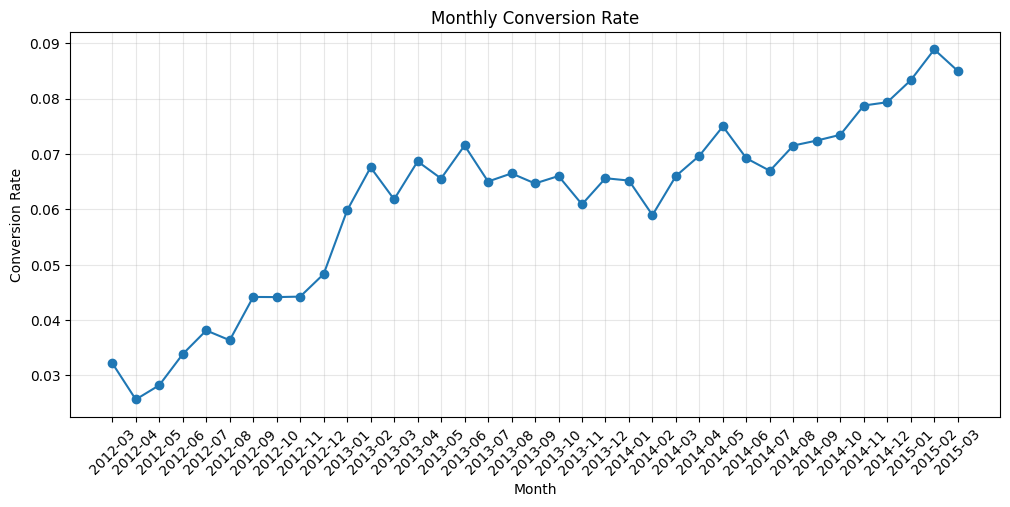

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary["session_month"],
    monthly_summary["conversion_rate"],
    marker="o"
)

plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

## 5.3. Bảng phân tích theo quý

Phân tích theo quý giúp nhìn bức tranh tổng quan hơn so với tháng.
Bảng này phù hợp khi sếp muốn xem overall performance theo từng giai đoạn lớn.

In [ ]:
quarterly_summary = (
    master_journey
    .groupby("session_quarter", as_index=False)
    .agg(
        sessions=("website_session_id", "nunique"),
        orders=("order_id", "count")
    )
)

quarterly_summary["dropoff_sessions"] = quarterly_summary["sessions"] - quarterly_summary["orders"]
quarterly_summary["conversion_rate"] = quarterly_summary["orders"] / quarterly_summary["sessions"]
quarterly_summary["dropoff_rate"] = quarterly_summary["dropoff_sessions"] / quarterly_summary["sessions"]

quarterly_summary = quarterly_summary.sort_values("session_quarter")

display(
    quarterly_summary.style.format({
        "conversion_rate": "{:.2%}",
        "dropoff_rate": "{:.2%}"
    })
)

,session_quarter,sessions,orders,dropoff_sessions,conversion_rate,dropoff_rate
0,2012Q1,1862,60,1802,3.22%,96.78%
1,2012Q2,10623,311,10312,2.93%,97.07%
2,2012Q3,15367,612,14755,3.98%,96.02%
3,2012Q4,28865,1312,27553,4.55%,95.45%
4,2013Q1,16690,1057,15633,6.33%,93.67%
5,2013Q2,21364,1465,19899,6.86%,93.14%
6,2013Q3,23397,1530,21867,6.54%,93.46%
7,2013Q4,34280,2196,32084,6.41%,93.59%
8,2014Q1,38244,2420,35824,6.33%,93.67%
9,2014Q2,42688,3045,39643,7.13%,92.87%


## 5.4. Bộ lọc dữ liệu theo tháng/quý

Cell dưới đây cho phép chọn một khoảng thời gian cụ thể để phân tích lại Sankey.

Cách dùng:
- Nếu muốn phân tích toàn bộ dữ liệu: để `TIME_FILTER_TYPE = "all"`.
- Nếu muốn lọc theo tháng: dùng `TIME_FILTER_TYPE = "month"` và nhập tháng vào `SELECTED_PERIOD`, ví dụ `"2013-04"`.
- Nếu muốn lọc theo quý: dùng `TIME_FILTER_TYPE = "quarter"` và nhập quý vào `SELECTED_PERIOD`, ví dụ `"2013Q2"`.

In [ ]:
TIME_FILTER_TYPE = "all"      # Chọn: "all", "month", hoặc "quarter"
SELECTED_PERIOD = None        # Ví dụ: "2013-04" nếu lọc theo tháng, "2013Q2" nếu lọc theo quý

if TIME_FILTER_TYPE == "all":
    filtered_journey = master_journey.copy()

elif TIME_FILTER_TYPE == "month":
    filtered_journey = master_journey[
        master_journey["session_month"] == SELECTED_PERIOD
    ].copy()

elif TIME_FILTER_TYPE == "quarter":
    filtered_journey = master_journey[
        master_journey["session_quarter"] == SELECTED_PERIOD
    ].copy()

else:
    raise ValueError("TIME_FILTER_TYPE chỉ được nhận: 'all', 'month', hoặc 'quarter'.")

print("Kiểu filter:", TIME_FILTER_TYPE)
print("Giai đoạn được chọn:", SELECTED_PERIOD)
print("Số session sau khi filter:", filtered_journey["website_session_id"].nunique())
print("Số order sau khi filter:", filtered_journey["order_id"].notna().sum())

Kiểu filter: all
Giai đoạn được chọn: None
Số session sau khi filter: 389543
Số order sau khi filter: 26195


# 6. Bổ sung: Gom cụm Landing Page cùng cấu trúc

## Mục đích
Một số Landing Page có cùng cấu trúc, ví dụ:

- `/lander-1`
- `/lander-2`
- `/lander-3`
- `/lander-4`
- `/lander-5`

Các trang này có thể được gom thành nhóm `/lander-template`.

Việc gom nhóm giúp:
- Nhìn performance tổng quan của một nhóm landing page.
- Chuẩn bị cho A/B Testing theo template.
- So sánh template landing page với các trang khác như `/home`.

In [ ]:
import re

def classify_landing_template(page_url):
    if pd.isna(page_url):
        return "Unknown Landing Page"

    if re.match(r"^/lander-\d+$", page_url):
        return "/lander-template"

    return page_url

master_journey["landing_page_template"] = master_journey["landing_page"].apply(classify_landing_template)

display(
    master_journey[[
        "landing_page",
        "landing_page_template"
    ]]
    .drop_duplicates()
    .sort_values("landing_page")
)

,landing_page,landing_page_template
0,/home,/home
10995,/lander-1,/lander-template
58712,/lander-2,/lander-template
96681,/lander-3,/lander-template
164783,/lander-4,/lander-template
249040,/lander-5,/lander-template


## 6.1. Đánh giá performance theo Landing Page Template

Bảng này cho biết nhóm Landing Page nào có:
- Nhiều session.
- Tỷ lệ chuyển đổi cao/thấp.
- Tỷ lệ Drop-off cao/thấp.

Nếu một template có traffic lớn nhưng drop-off rate cao, đó là nhóm nên được ưu tiên kiểm tra hoặc A/B Testing.

In [ ]:
landing_template_summary = (
    master_journey
    .groupby("landing_page_template", as_index=False)
    .agg(
        sessions=("website_session_id", "nunique"),
        orders=("order_id", "count")
    )
)

landing_template_summary["dropoff_sessions"] = (
    landing_template_summary["sessions"] - landing_template_summary["orders"]
)

landing_template_summary["conversion_rate"] = (
    landing_template_summary["orders"] / landing_template_summary["sessions"]
)

landing_template_summary["dropoff_rate"] = (
    landing_template_summary["dropoff_sessions"] / landing_template_summary["sessions"]
)

landing_template_summary = landing_template_summary.sort_values(
    ["sessions", "dropoff_rate"],
    ascending=[False, False]
)

display(
    landing_template_summary.style.format({
        "conversion_rate": "{:.2%}",
        "dropoff_rate": "{:.2%}"
    })
)

,landing_page_template,sessions,orders,dropoff_sessions,conversion_rate,dropoff_rate
1,/lander-template,335295,22602,312693,6.74%,93.26%
0,/home,54248,3593,50655,6.62%,93.38%


## Nhận xét template Landing Page

Sau khi chạy bảng trên, có thể nhận xét theo logic sau:

- Nếu `/lander-template` có traffic lớn nhưng drop-off rate cao, doanh nghiệp nên kiểm tra lại cấu trúc chung của nhóm landing page này.
- Nếu một landing page riêng lẻ như `/home` có conversion rate tốt hơn, có thể so sánh layout, nội dung, CTA của `/home` với nhóm `/lander-template`.
- Việc gom cụm này giúp chuẩn bị cho A/B Testing: giữ nguyên traffic source, chỉ thay đổi template landing page để đo tác động đến conversion rate.

# 7. Cải thiện Visualization: Sankey có màu theo loại flow

## Mục đích
Để người xem dễ nhận biết luồng nào đang bị rơi rụng, ta tô màu flow như sau:

- Luồng đi tới `None (Drop-off)`: màu đỏ nhạt.
- Luồng đi tới sản phẩm: màu xanh nhạt.
- Luồng từ `utm_source` sang `landing_page`: màu xám nhạt.

Cách tô màu này giúp người xem dễ phát hiện phần phễu bị thủng.

In [ ]:
# Dùng filtered_journey nếu đã chạy phần filter tháng/quý
# Nếu chưa chạy phần filter, fallback về master_journey
try:
    sankey_base = filtered_journey.copy()
except NameError:
    sankey_base = master_journey.copy()

# Tầng 1: utm_source -> landing_page
layer_1_filtered = (
    sankey_base
    .groupby(["utm_source", "landing_page"], as_index=False)
    .agg(value=("website_session_id", "nunique"))
    .rename(columns={
        "utm_source": "source",
        "landing_page": "target"
    })
)

layer_1_filtered["flow_type"] = "Traffic to Landing Page"

# Tầng 2: landing_page -> product_name / Drop-off
layer_2_filtered = (
    sankey_base
    .groupby(["landing_page", "product_name"], as_index=False)
    .agg(value=("website_session_id", "nunique"))
    .rename(columns={
        "landing_page": "source",
        "product_name": "target"
    })
)

layer_2_filtered["flow_type"] = layer_2_filtered["target"].apply(
    lambda x: "Drop-off" if x == "None (Drop-off)" else "Purchase"
)

sankey_links_colored = pd.concat(
    [layer_1_filtered, layer_2_filtered],
    ignore_index=True
)

display(sankey_links_colored.head())

,source,target,value,flow_type
0,bsearch,/home,7914,Traffic to Landing Page
1,bsearch,/lander-1,9459,Traffic to Landing Page
2,bsearch,/lander-2,24076,Traffic to Landing Page
3,bsearch,/lander-3,6178,Traffic to Landing Page
4,bsearch,/lander-4,1903,Traffic to Landing Page


In [ ]:
# Tạo danh sách node
all_nodes_colored = pd.Index(
    pd.concat([
        sankey_links_colored["source"],
        sankey_links_colored["target"]
    ]).unique()
)

node_map_colored = {
    node: idx for idx, node in enumerate(all_nodes_colored)
}

sankey_links_colored["source_id"] = sankey_links_colored["source"].map(node_map_colored)
sankey_links_colored["target_id"] = sankey_links_colored["target"].map(node_map_colored)

# Màu flow
def get_link_color(flow_type):
    if flow_type == "Drop-off":
        return "rgba(255, 99, 132, 0.35)"     # đỏ nhạt
    elif flow_type == "Purchase":
        return "rgba(46, 204, 113, 0.35)"     # xanh nhạt
    else:
        return "rgba(160, 160, 160, 0.25)"    # xám nhạt

sankey_links_colored["link_color"] = sankey_links_colored["flow_type"].apply(get_link_color)

# Màu node
def get_node_color(node):
    if node == "None (Drop-off)":
        return "rgba(255, 99, 132, 0.8)"
    elif node in products["product_name"].dropna().unique():
        return "rgba(46, 204, 113, 0.8)"
    elif node in master_journey["utm_source"].dropna().unique():
        return "rgba(52, 152, 219, 0.8)"
    else:
        return "rgba(241, 196, 15, 0.8)"

node_colors = [get_node_color(node) for node in all_nodes_colored]

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=20,
                thickness=18,
                label=all_nodes_colored.tolist(),
                color=node_colors
            ),
            link=dict(
                source=sankey_links_colored["source_id"],
                target=sankey_links_colored["target_id"],
                value=sankey_links_colored["value"],
                color=sankey_links_colored["link_color"],
                customdata=sankey_links_colored["flow_type"],
                hovertemplate=(
                    "Source: %{source.label}<br>"
                    "Target: %{target.label}<br>"
                    "Sessions: %{value:,}<br>"
                    "Flow type: %{customdata}"
                    "<extra></extra>"
                )
            )
        )
    ]
)

fig.update_layout(
    title_text="Customer Journey Sankey with Drop-off Highlight",
    font_size=11,
    height=750
)

fig.show()

# 8. Nhận xét bổ sung sau khi tối ưu

## 1. Phân tích theo tháng/quý
Việc bổ sung phân tích theo tháng/quý giúp theo dõi conversion rate và drop-off rate theo thời gian. Nếu một tháng hoặc quý có drop-off tăng bất thường, doanh nghiệp nên kiểm tra lại các thay đổi trong giai đoạn đó, ví dụ:
- Thay đổi giao diện website.
- Thay đổi nội dung quảng cáo.
- Thay đổi landing page.
- Lỗi kỹ thuật hoặc tốc độ tải trang.

## 2. Gom cụm Landing Page
Việc gom các landing page có cùng cấu trúc thành template giúp đánh giá hiệu quả ở cấp độ tổng quan hơn. Nếu nhóm `/lander-template` có drop-off rate cao, vấn đề có thể không nằm ở một landing page riêng lẻ mà nằm ở cấu trúc chung của template.

## 3. Sankey có màu
Sankey sau khi thêm màu giúp người xem dễ nhận biết:
- Flow màu đỏ là luồng rơi rụng, dẫn đến `None (Drop-off)`.
- Flow màu xanh là luồng có chuyển đổi thành đơn hàng.
- Flow màu xám là luồng từ nguồn traffic sang landing page.

Cách trình bày này giúp phát hiện nhanh đoạn phễu bị thủng và hỗ trợ việc ra quyết định tối ưu website.